Web scraping project

In [3]:
pip install requests beautifulsoup4 pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
import requests
from bs4 import BeautifulSoup

In [7]:
url="https://www.scrapethissite.com/pages/forms/" # get webpage html
response=requests.get(url)

In [9]:
print(response.status_code) #2000 means success or correct

200


In [11]:
#convert html into readable format
soup=BeautifulSoup(response.text,"html.parser")
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Hockey Teams: Forms, Searching and Pagination | Scrape This Site | A public sandbox for learning web scraping
  </title>
  <link href="/static/images/scraper-icon.png" rel="icon" type="image/png"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <meta content="Browse through a database of NHL team stats since 1990. Practice building a scraper that handles common website interface components." name="description"/>
  <link crossorigin="anonymous" href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.5/css/bootstrap.min.css" integrity="sha256-MfvZlkHCEqatNoGiOXveE8FIwMzZg4W85qfrfIFBfYc= sha512-dTfge/zgoMYpP7QbHy4gWMEGsbsdZeCXz7irItjcC3sPUFtf0kuFbDz/ixG7ArTxmDjLXDmezHubeNikyKGVyQ==" rel="stylesheet"/>
  <link href="https://fonts.googleapis.com/css?family=Lato:400,700" rel="stylesheet" type="text/css"/>
  <link href="/static/css/styles.css" rel="stylesheet" type="text/css"/>
  <meta con

In [13]:
#find every team row 
rows=soup.find_all("tr",class_="team")
print(rows)

[<tr class="team">
<td class="name">
                            Boston Bruins
                        </td>
<td class="year">
                            1990
                        </td>
<td class="wins">
                            44
                        </td>
<td class="losses">
                            24
                        </td>
<td class="ot-losses">
</td>
<td class="pct text-success">
                            0.55
                        </td>
<td class="gf">
                            299
                        </td>
<td class="ga">
                            264
                        </td>
<td class="diff text-success">
                            35
                        </td>
</tr>, <tr class="team">
<td class="name">
                            Buffalo Sabres
                        </td>
<td class="year">
                            1990
                        </td>
<td class="wins">
                            31
                        </td>
<td 

In [15]:
print("total rows found ",len(rows))

total rows found  25


In [17]:
# extracting same as you can see in website
data = [] #Creates an empty list #This list will store one dictionary per team per year

for row in rows:
    team_name = row.find("td", class_="name").text.strip() #.text → extract text inside tag
    year = row.find("td", class_="year").text.strip() # .strip() → remove extra spaces & new lines
    wins = row.find("td", class_="wins").text.strip()
    losses = row.find("td", class_="losses").text.strip()
    OT_Losses = row.find("td", class_="ot-losses").text.strip() # class ka dhyan se dekh k
    win_percentage = row.find("td", class_="pct").text.strip() # starting ka hi put kro hojaega usse
    GF = row.find("td", class_="gf").text.strip()
    GA = row.find("td", class_="ga").text.strip()
    plus_minus = row.find("td", class_="diff").text.strip()

    data.append({ ## Create one dictionary (one row)
        "Team Name": team_name, # Keys = column names
        "Year": year,           # Values = scraped values
        "Wins": wins,
        "Losses": losses,
        "OT losses": OT_Losses,
        "win %": win_percentage,
        "GF": GF,
        "GA": GA,
        "+/-": plus_minus
        
    })

In [19]:
# create table
import pandas as pd
df1=pd.DataFrame(data)#DataFrame is a 2-dimensional table for making data a structured

In [21]:
df1

,Team Name,Year,Wins,Losses,OT losses,win %,GF,GA,+/-
0,Boston Bruins,1990,44,24,,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,,0.463,272,272,0
6,Hartford Whalers,1990,31,38,,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,,0.487,273,249,24


In [23]:
# remove ot losses column
df2=df1.drop(columns=['OT losses'])

In [25]:
df2

,Team Name,Year,Wins,Losses,win %,GF,GA,+/-
0,Boston Bruins,1990,44,24,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,0.388,292,278,14
2,Calgary Flames,1990,46,26,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,0.463,272,272,0
6,Hartford Whalers,1990,31,38,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,0.487,273,249,24


In [27]:
# identify duplicates and remove it and clean the data
print(df2.duplicated()) # check

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
dtype: bool


In [29]:
#count duplicates
print(df2.duplicated().sum())

0


In [31]:
# remove duplicate rows
df3=df2.drop_duplicates

In [33]:
df3

<bound method DataFrame.drop_duplicates of                 Team Name  Year Wins Losses  win %   GF   GA   +/-
0           Boston Bruins  1990   44     24   0.55  299  264    35
1          Buffalo Sabres  1990   31     30  0.388  292  278    14
2          Calgary Flames  1990   46     26  0.575  344  263    81
3      Chicago Blackhawks  1990   49     23  0.613  284  211    73
4       Detroit Red Wings  1990   34     38  0.425  273  298   -25
5         Edmonton Oilers  1990   37     37  0.463  272  272     0
6        Hartford Whalers  1990   31     38  0.388  238  276   -38
7       Los Angeles Kings  1990   46     24  0.575  340  254    86
8   Minnesota North Stars  1990   27     39  0.338  256  266   -10
9      Montreal Canadiens  1990   39     30  0.487  273  249    24
10      New Jersey Devils  1990   32     33    0.4  272  264     8
11     New York Islanders  1990   25     45  0.312  223  290   -67
12       New York Rangers  1990   36     31   0.45  297  265    32
13    Philadelphia 

In [35]:
#df4=pd.DataFrame(df3) not worked
# change the data type , imp for visualisation 
#error 
df3["Year"] = df3["Year"].astype(int)
df3["Wins"] = df3["Wins"].astype(int)
df3["Losses"] = df3["Losses"].astype(int)
df3["win %"] = df3["Year"].astype(int)
df3["GF"] = df3["Wins"].astype(int)
df3["GA"] = df3["Losses"].astype(int)
df3["+/-"] = df3["Year"].astype(int)


TypeError: 'method' object is not subscriptable

In [37]:
# correction
df3 = df2.drop_duplicates()

In [39]:
df3

,Team Name,Year,Wins,Losses,win %,GF,GA,+/-
0,Boston Bruins,1990,44,24,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,0.388,292,278,14
2,Calgary Flames,1990,46,26,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,0.463,272,272,0
6,Hartford Whalers,1990,31,38,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,0.487,273,249,24


In [41]:
df3["Team Name"] = df3["Team Name"].astype(str)
df3["Year"] = df3["Year"].astype(int)
df3["Wins"] = df3["Wins"].astype(int)
df3["Losses"] = df3["Losses"].astype(int)
df3["win %"] = df3["win %"].astype(float) # key error means not having that column #
df3["GF"] = df3["GF"].astype(int)
df3["GA"] = df3["GA"].astype(int)
df3["+/-"] = df3["+/-"].astype(int)

In [43]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Team Name  25 non-null     object 
 1   Year       25 non-null     int32  
 2   Wins       25 non-null     int32  
 3   Losses     25 non-null     int32  
 4   win %      25 non-null     float64
 5   GF         25 non-null     int32  
 6   GA         25 non-null     int32  
 7   +/-        25 non-null     int32  
dtypes: float64(1), int32(6), object(1)
memory usage: 1.1+ KB


In [45]:
df3

,Team Name,Year,Wins,Losses,win %,GF,GA,+/-
0,Boston Bruins,1990,44,24,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,0.388,292,278,14
2,Calgary Flames,1990,46,26,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,0.463,272,272,0
6,Hartford Whalers,1990,31,38,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,0.487,273,249,24


In [47]:
df3 

,Team Name,Year,Wins,Losses,win %,GF,GA,+/-
0,Boston Bruins,1990,44,24,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,0.388,292,278,14
2,Calgary Flames,1990,46,26,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,0.463,272,272,0
6,Hartford Whalers,1990,31,38,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,0.487,273,249,24


In [49]:
# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
df4=df3[df3["Year"]==1990]

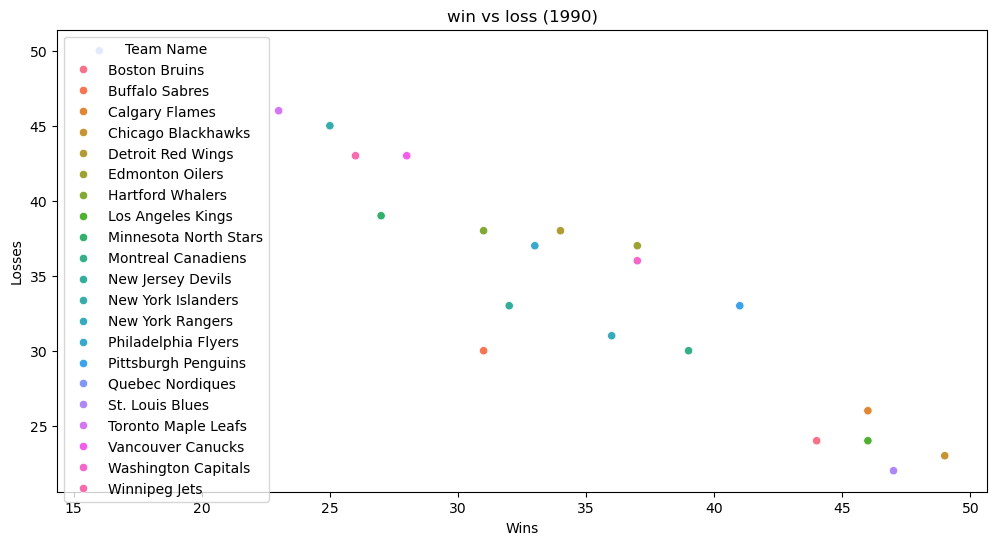

In [51]:
plt.figure(figsize=(12,6)) # 12 is width , 6 height (units are in inches)
sns.scatterplot(x="Wins",y="Losses",data=df4, hue ="Team Name") # hue makes colour of different teams
plt.title("win vs loss (1990)")
plt.show()

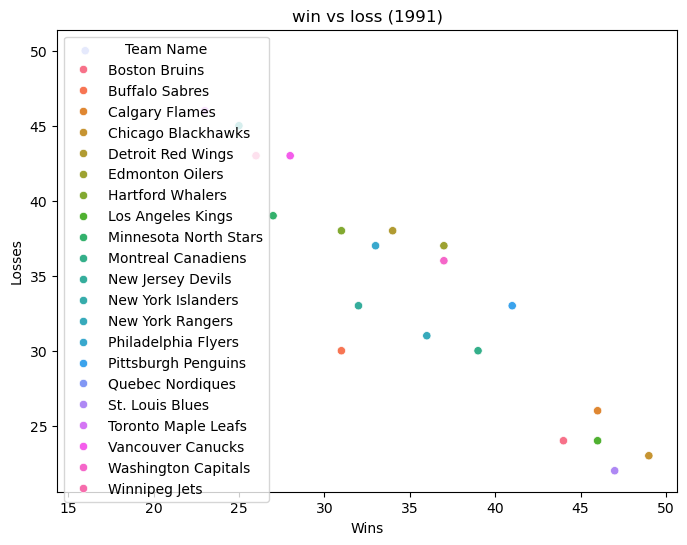

In [53]:
df5=df3[df3["Year"]==1991]
plt.figure(figsize=(8,6))
sns.scatterplot(x="Wins",y="Losses",data=df4, hue ="Team Name")
plt.title("win vs loss (1991)")
plt.show()

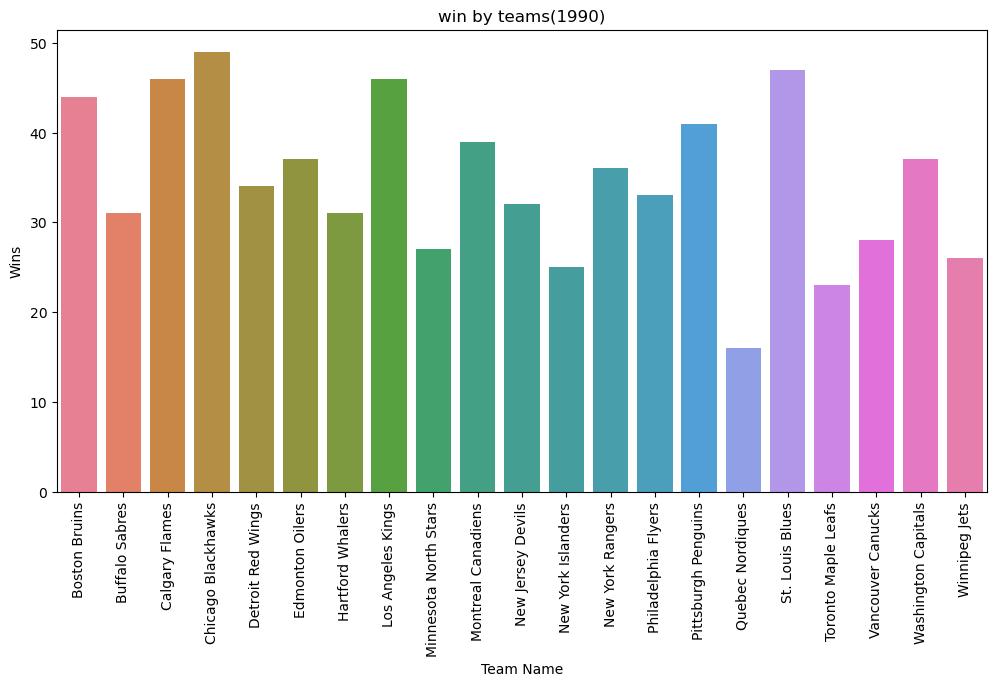

In [55]:
df6=df3[df3["Year"]==1990]
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="Wins",data=df4, hue ="Team Name")
plt.xticks(rotation=90) # rotates the labels on x axis( 0 for horizontal,45 for tilted,90 vertical)
plt.title("win by teams(1990)")
plt.show()

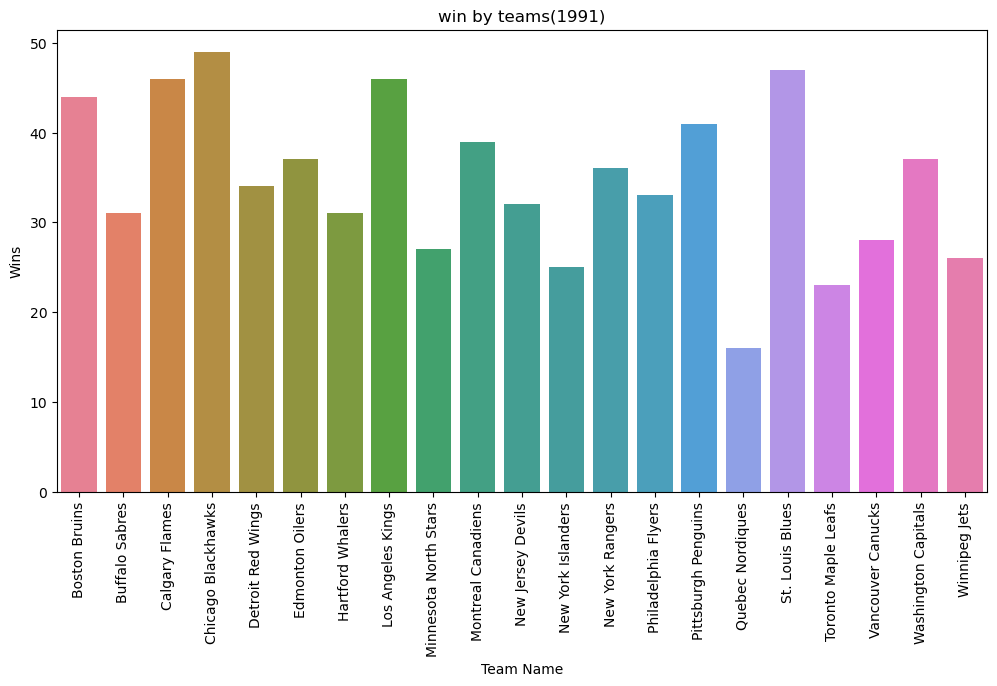

In [57]:
df7=df3[df3["Year"]==1991]
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="Wins",data=df4, hue ="Team Name")
plt.xticks(rotation=90) # isse team names clear dikhega
plt.title("win by teams(1991)")
plt.show()

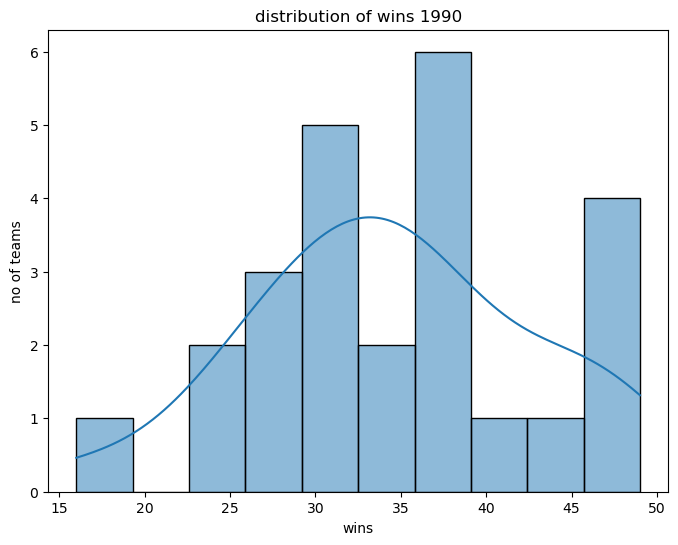

In [59]:
plt.figure(figsize=(8,6))
sns.histplot(df3["Wins"],bins=10,kde=True) # bins divide data into 10 groups # kde for smooth curve distribution
plt.title("distribution of wins 1990")
plt.xlabel("wins")
plt.ylabel("no of teams")
plt.show()

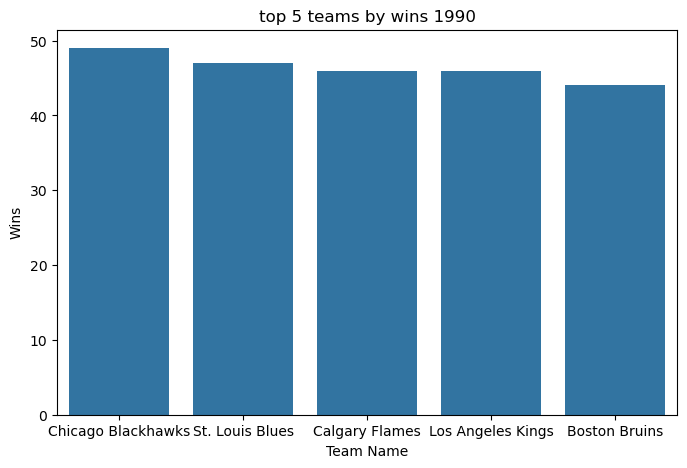

In [61]:
df8=df3[df3["Year"]==1990]
top_teams=df8.sort_values(by="Wins",ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x="Team Name" , y="Wins",data=top_teams)
plt.title("top 5 teams by wins 1990")
plt.show()

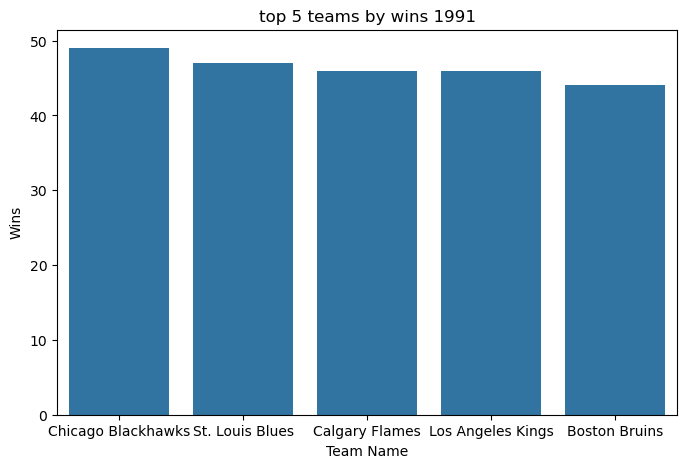

In [63]:
df9=df3[df3["Year"]==1991]
top_teams=df8.sort_values(by="Wins",ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x="Team Name" , y="Wins",data=top_teams)
plt.title("top 5 teams by wins 1991")
plt.show()

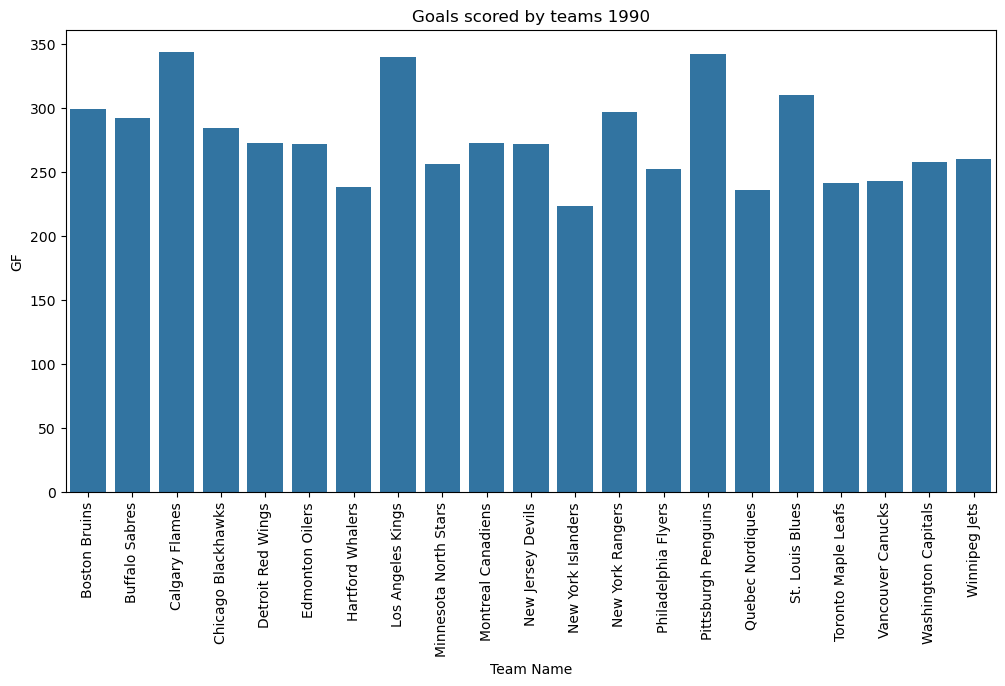

In [65]:
# Which teams score the most goals?
df10=df3[df3["Year"]==1990]
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="GF",data=df10)
plt.xticks(rotation=90)
plt.title("Goals scored by teams 1990")
plt.show()

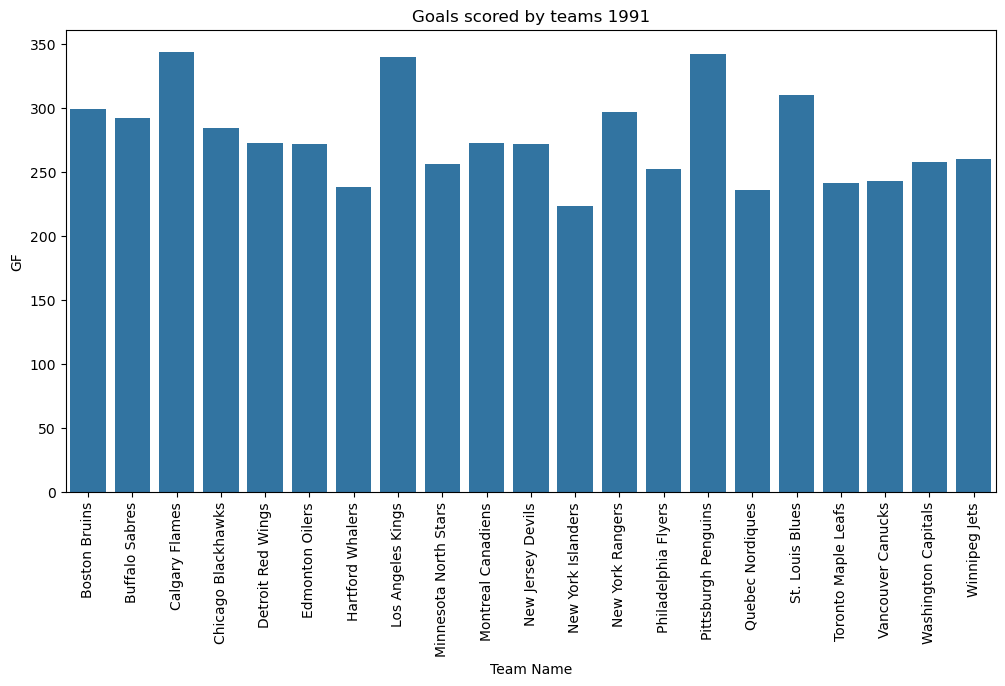

In [67]:
df11=df3[df3["Year"]==1991]
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="GF",data=df10)
plt.xticks(rotation=90)
plt.title("Goals scored by teams 1991")
plt.show()

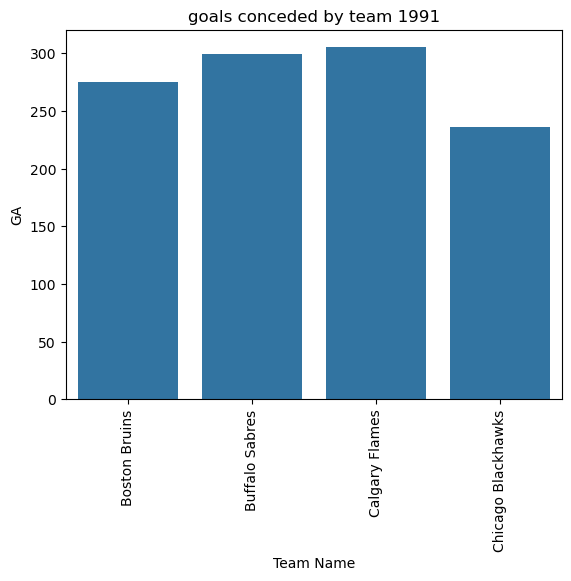

In [69]:
# Which teams have the best defense?
df12=df3[df3["Year"]==1991]
sns.barplot(x="Team Name",y="GA",data=df12)
plt.xticks(rotation=90)
plt.title("goals conceded by team 1991")
plt.show()

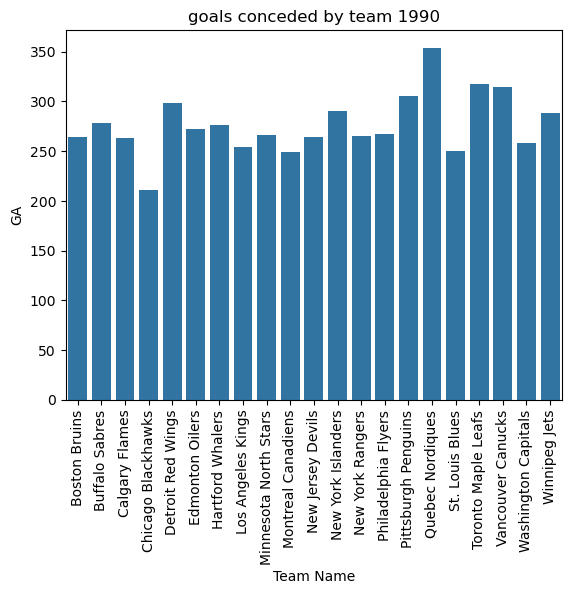

In [71]:
df13=df3[df3["Year"]==1990]
sns.barplot(x="Team Name",y="GA",data=df13)
plt.xticks(rotation=90)
plt.title("goals conceded by team 1990")
plt.show()

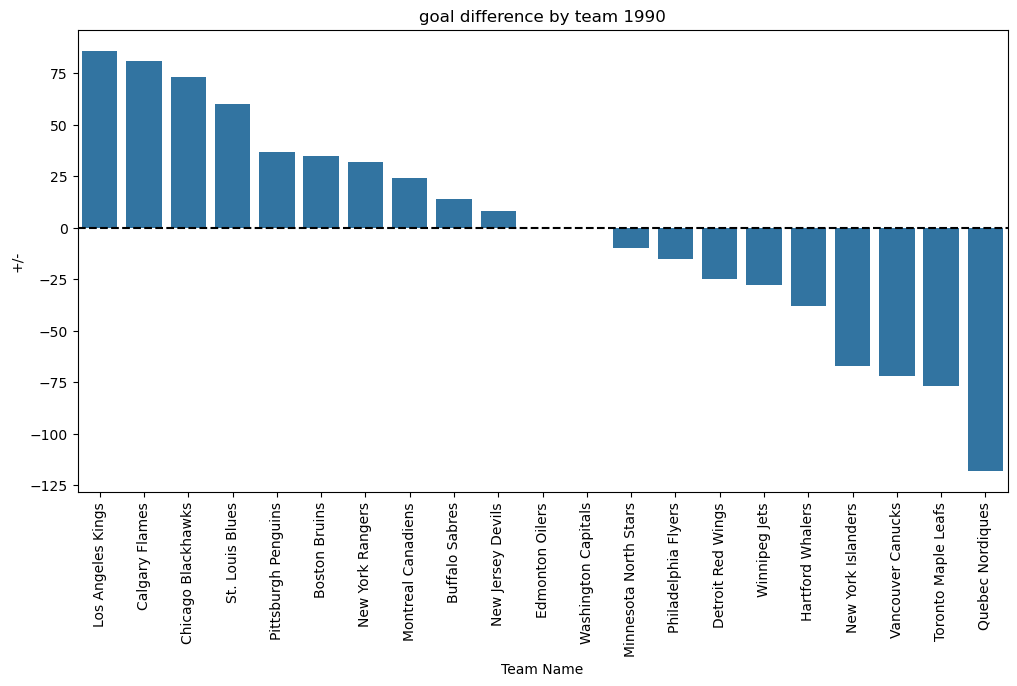

In [73]:
# Which teams dominate overall?
df14=df13.sort_values(by="+/-",ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="+/-",data=df14)
plt.xticks(rotation=90)
plt.title("goal difference by team 1990")
plt.axhline(0,color='black',linestyle='--')# above 0 strong teams,below 0 weak teams
plt.show()

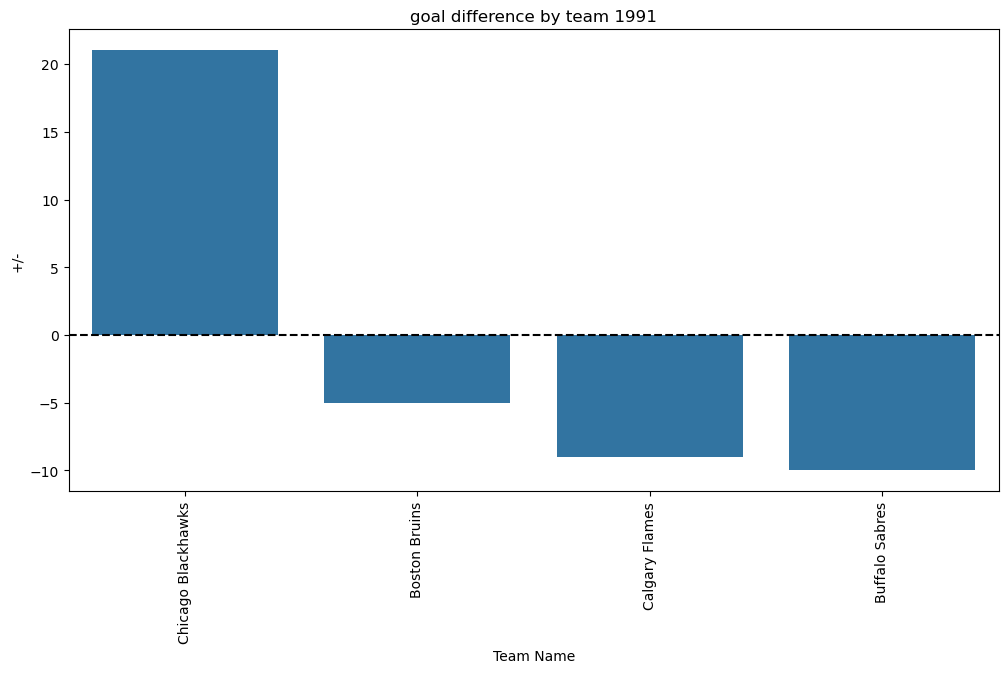

In [75]:
df15=df12.sort_values(by="+/-",ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x="Team Name",y="+/-",data=df15)
plt.xticks(rotation=90)
plt.title("goal difference by team 1991")
plt.axhline(0,color='black',linestyle='--')# above 0 strong teams,below 0 weak teams
plt.show()

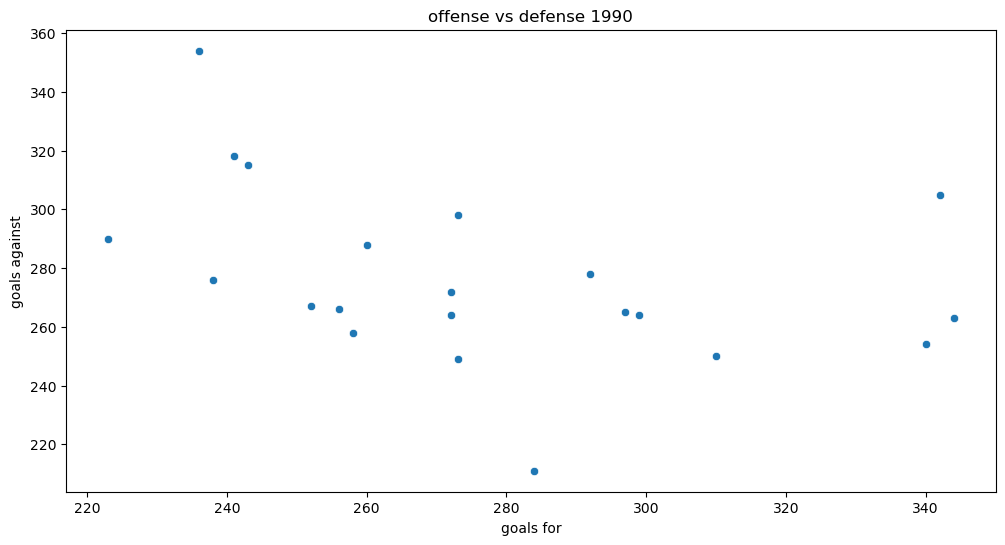

In [77]:
#Are high-scoring teams also good defensively?
df16=df13
plt.figure(figsize=(12,6))
sns.scatterplot(x="GF",y="GA",data=df16)
plt.xlabel("goals for")
plt.ylabel("goals against")
plt.title("offense vs defense 1990")
plt.show() # top left means strong attack and strong defense # bottom right means weak teams

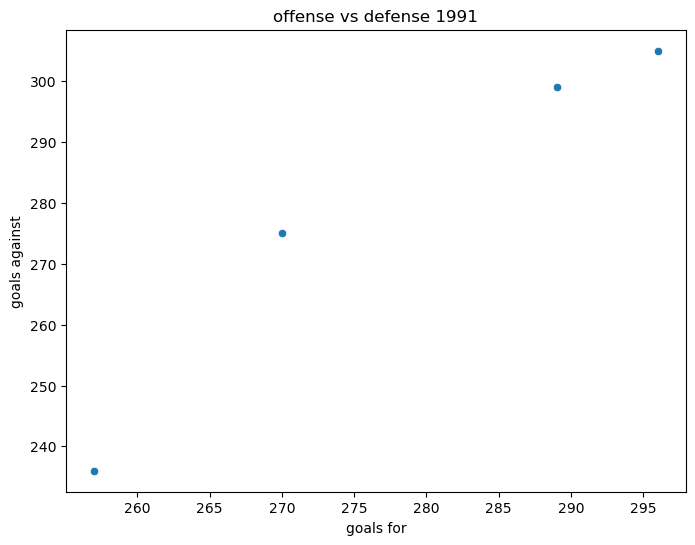

In [79]:
df17=df12
plt.figure(figsize=(8,6))
sns.scatterplot(x="GF",y="GA",data=df17)
plt.xlabel("goals for")
plt.ylabel("goals against")
plt.title("offense vs defense 1991")
plt.show()

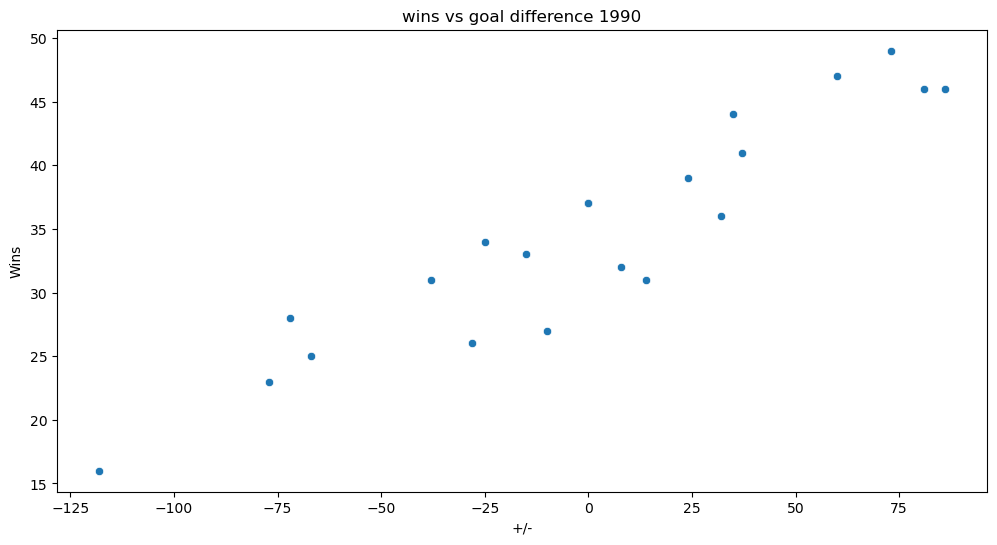

In [81]:
# Does higher +/− lead to more wins?
df18=df13
plt.figure(figsize=(12,6))
sns.scatterplot(x="+/-",y="Wins",data=df18)
plt.title("wins vs goal difference 1990")
plt.show()
# positive correlation=goal dominance leads to wins

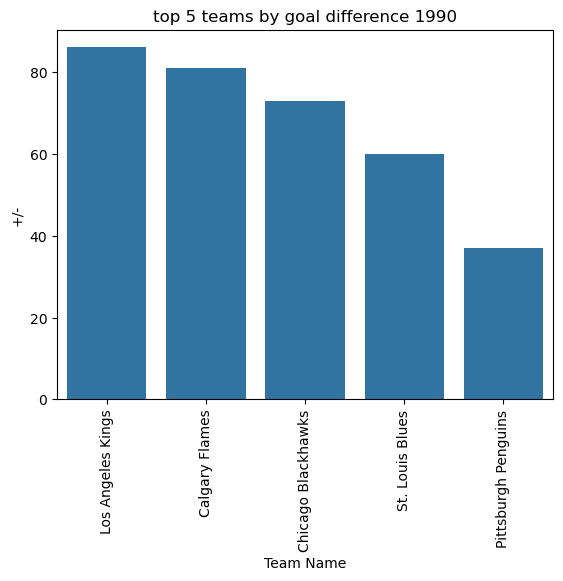

In [83]:
# Which teams dominate both scoring & defense?
df19=df13.sort_values(by="+/-",ascending=False).head(5)
sns.barplot(x="Team Name",y="+/-",data=df19)
plt.xticks(rotation=90)
plt.title("top 5 teams by goal difference 1990")
plt.show()

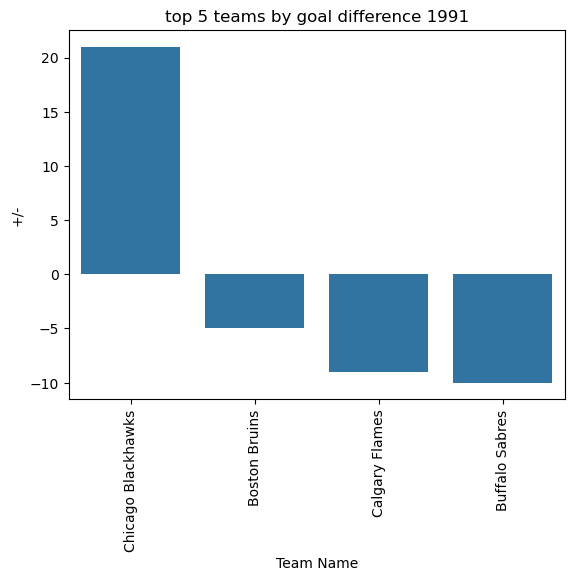

In [91]:
df20=df12.sort_values(by="+/-",ascending=False).head(5)
sns.barplot(x="Team Name",y="+/-",data=df20)
plt.xticks(rotation=90)
plt.title("top 5 teams by goal difference 1991")
plt.show()